## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1. The difference between regression and classification is that they are trying to create different outputs. 
- Regression is used when the intended output is numerical. You are predicting a quantity.
    - Ex: based on year and mileage of a car, regression can predict its price.
- Classification is used when the intended output is categorical. You are predicting a label or group. 
    - Ex: based on year and mileage of a car, predict the type of car. 
2. A confusion matrix is a cross-tabulation of predicted and actual values. It compares the Predicted Labels against the Actual Labels.
3. Accuracy is the proportion of predictions that were correct (#correct/Ntest). It might not be entirely sufficient to evaluate a classifier's predictive performance because it ignores the practical asymmetry between a false positive and a false negative.
4. The root mean squared error quantifies the distance from the true values to the predicted ones, weighted by sample size (as n gets large, these values typically approach some fixed value). 
5. Underfitting occurs when the model is too simple to reliably explain the phenomenon you are interested in ($k$ is very small), and overfitting occurs when your model is too complex to reliably explain the phenomenon you are interested in ($k$ is very large). 
6. Splitting the data into training and testing sets is crucial because we want to imagine how the model with perform in plausible situations which the model has not yet seen. So, if we train the model with some of the data and test it with the rest, we can see how well it performs with unseen data and make crucial changes so it will better predict the test data. Additionally, choosing $k$ based on evaluating accuracy or RMSE improves model performance because we want to maximize accuracy or minimize our error function (MSE) for $k$.
7.
- The strengths of predictions are that they are simple, binary, and actionable for automated systems
- The weaknesses of predictions are that hide the model's uncertainty: a 51% certainty looks the same as 99%.
- The strengths of probabilities are that they provide nuance and allow humans to set custom thresholds for risk.
- The weaknesses of probabilities are that they require more interpretation and cannot be used directly with a cutoff point. 

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1 

(338, 4) 

Target Label Distribution:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 

Statistical Summary of Features:
           count      mean       std       min       25%       50%       75%  \
voltage    338.0  0.430634  0.195819  0.197734  0.309737  0.359516  0.482628   
height     338.0  0.508876  0.306043  0.000000  0.272727  0.545455  0.727273   
soil       338.0  0.503550  0.344244  0.000000  0.200000  0.600000  0.800000   
mine_type  338.0  2.952663  1.419703  1.000000  2.000000  3.000000  4.000000   

                max  
voltage    0.999999  
height     1.000000  
soil       1.000000  
mine_type  5.000000   



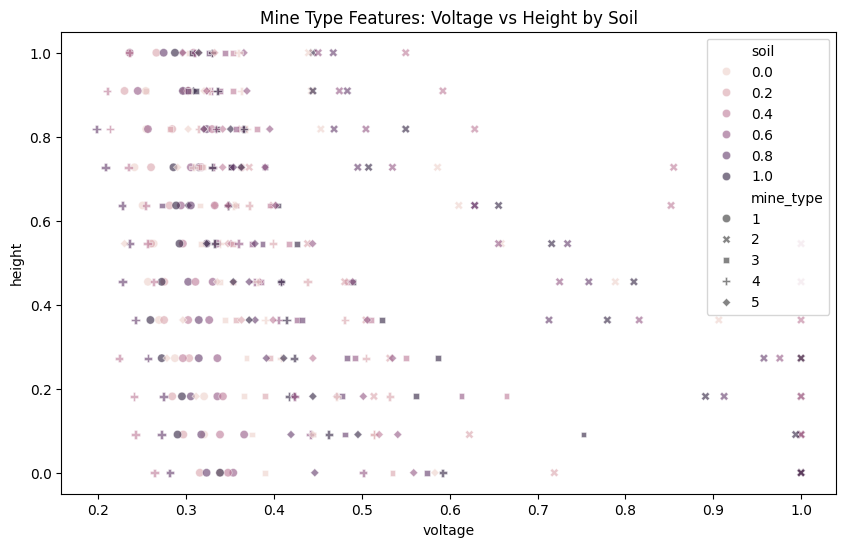

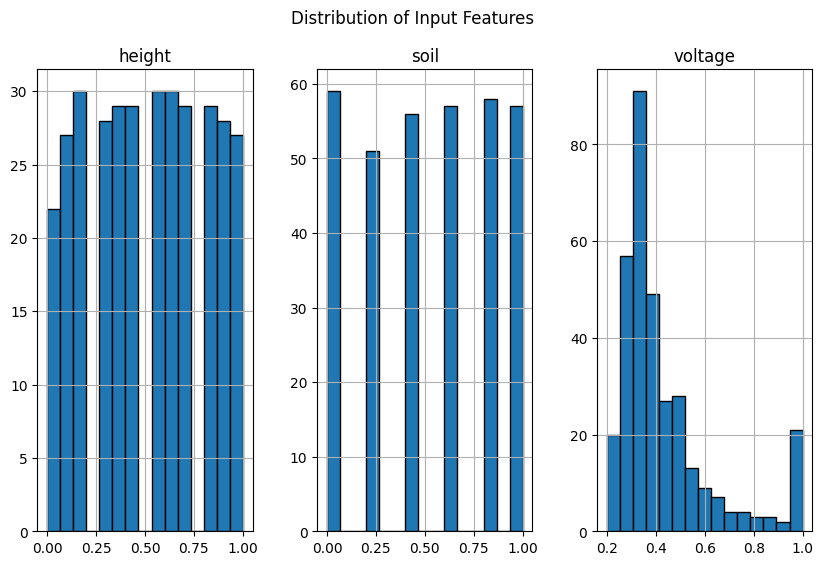

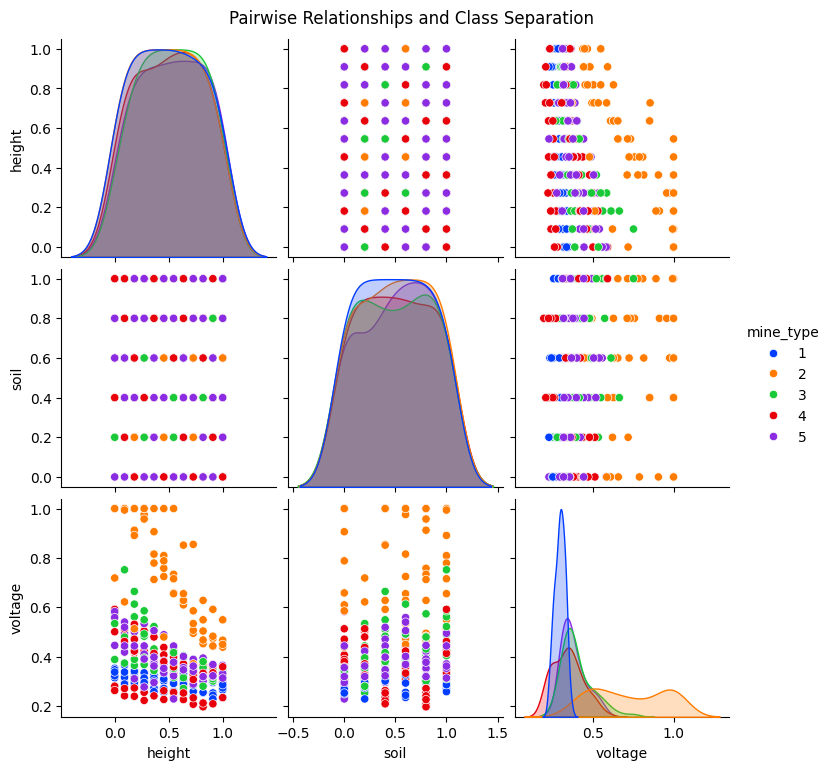

In [198]:
#1
df = pd.read_csv("../data/land_mines.csv")
print(df.head(), "\n")
print(df.shape, "\n")
print("Target Label Distribution:\n", df['mine_type'].value_counts(), "\n")

print("Statistical Summary of Features:")
print(df.describe().T, "\n")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['voltage'], 
                y = df['height'],
                hue = df['soil'],
                style=df['mine_type'],
                alpha=.6)
plt.title("Mine Type Features: Voltage vs Height by Soil")
plt.show()

df[ctrl_list].hist(bins=15, figsize=(10, 6), layout=(1, 3), edgecolor='black')
plt.suptitle("Distribution of Input Features")
plt.show()

sns.pairplot(df, hue='mine_type', vars=ctrl_list, palette='bright', diag_kind='kde')
plt.suptitle("Pairwise Relationships and Class Separation", y=1.02)
plt.show()

In [199]:
#2
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

y = df['mine_type']
ctrl_list = [ 'height', 'soil', 'voltage' ]
x = df.loc[:, ctrl_list] 
u = x.apply(minmax) 

from sklearn.model_selection import train_test_split
u_train, u_test, y_train, y_test = train_test_split(u,y, test_size=.5, random_state=100)

k = 5 model score: 0.3905325443786982
Test accuracy for 3 neighbors is 0.40828402366863903; train accuracy for 3 neighbors is 0.6449704142011834
Test accuracy for 5 neighbors is 0.3905325443786982; train accuracy for 5 neighbors is 0.5798816568047337
Test accuracy for 7 neighbors is 0.3609467455621302; train accuracy for 7 neighbors is 0.5857988165680473
Test accuracy for 9 neighbors is 0.3727810650887574; train accuracy for 9 neighbors is 0.5384615384615384
Test accuracy for 11 neighbors is 0.40236686390532544; train accuracy for 11 neighbors is 0.5266272189349113
Test accuracy for 13 neighbors is 0.40236686390532544; train accuracy for 13 neighbors is 0.5325443786982249
Test accuracy for 15 neighbors is 0.378698224852071; train accuracy for 15 neighbors is 0.4970414201183432
Test accuracy for 17 neighbors is 0.38461538461538464; train accuracy for 17 neighbors is 0.4319526627218935
Test accuracy for 19 neighbors is 0.35502958579881655; train accuracy for 19 neighbors is 0.46153846153

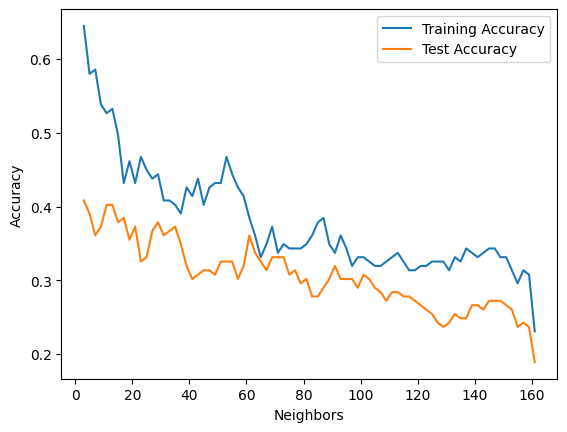

optimal k: [3]
We selected k by finding the maximum test accuracy. In this case, the test accuracy is maximized at [3]


In [200]:
#3
k = 5 
model = KNeighborsClassifier(n_neighbors = k) 
model = model.fit(u_train,y_train) 
y_hat = model.predict(u_test) 
print("k = 5 model score:", model.score(u_test,y_test))

k_grid = np.array([(2*k+3) for k in range(0,80)])
test_accuracies = []
train_accuracies = []

for k in k_grid: 
  model = KNeighborsClassifier(n_neighbors = k) 
  model = model.fit(u_train,y_train) 
  y_hat = model.predict(u_test) 
  test_acc = model.score(u_test,y_test) 
  train_acc = model.score(u_train,y_train)
  print( f'Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}') 
  test_accuracies.append(test_acc) 
  train_accuracies.append(train_acc)

sns.lineplot(x=k_grid,y=train_accuracies,label='Training Accuracy').set(xlabel='Neighbors',ylabel='Accuracy')
sns.lineplot(x=k_grid,y=test_accuracies,label='Test Accuracy')
plt.show()

is_optimal = test_accuracies == np.max(test_accuracies) 
optimal_indices = np.where(is_optimal) 
k_optimal = k_grid[optimal_indices] 

print("optimal k:", k_optimal)
print("We selected k by finding the maximum test accuracy. In this case, the test accuracy is maximized at", k_optimal)

In [201]:
#4 
k = 3
model = KNeighborsClassifier(n_neighbors = k) 
model = model.fit(u_train,y_train) 
y_hat = model.predict(u_test) 
print("Confusion matrix: \n", pd.crosstab(y_test, y_hat, rownames=['Actual'], colnames=['Predicted']))
accuracy = model.score(u_test,y_test)
print(f"\nOverall Test Accuracy: {accuracy:.2%}")
print("The performance is more accurate for mine types 1 and 2 while it's less accurate for mine types 4 and 5.")

Confusion matrix: 
 Predicted   1   2   3  4   5
Actual                      
1          28   0   5  3   2
2           0  24   5  2   4
3           8   0  10  3  12
4          17   2  11  4   1
5          12   0  11  2   3

Overall Test Accuracy: 40.83%
The performance is more accurate for mine types 1 and 2 while it's less accurate for mine types 4 and 5.


#5
I would advise someone to proceed with caution when the model predicts mine types 3, 4, and 5. When the model predicts a 5, the mine is more often a 3. When the model predicts a 4, there is a huge variety of what the actual results are. Finally, when the model predicts a 3, it is more often a 4 or 5. 

Similarly, the model predicts mine type 1 a lot. So, if I received a prediction of mine type 1, I would be prepared for the mine to be type 3, 4, or 5. 

The most accurate predictions for mine type came from type 2, whose predictions were correct 24/26 times. I would likely trust a prediction of mine type 2. 

So, when using this model in practice, I would be prepared for inaccuracy, especially with mine types 3, 4, and 5. 

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [202]:
#1
df2 = pd.read_csv("../data/USA_cars_datasets.csv")
df2 = df2.loc[:,['price', 'year', 'mileage']]
print(df2.head(), "\n")
print(df2.shape, "\n")
print("Missing Values:\n", df.isna().sum())

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654 

(2499, 3) 

Missing Values:
 voltage      0
height       0
soil         0
mine_type    0
dtype: int64


In [203]:
#2
u2 = df2.loc[:,['year', 'mileage']].apply(minmax)
u2.head()

,year,mileage
0,0.744681,0.269287
1,0.808511,0.187194
2,0.957447,0.038892
3,0.872340,0.063016
4,0.957447,0.006537


In [204]:
#3
y2 = df2['price']
u2_train, u2_test, y2_train, y2_test = train_test_split(u2,y2, test_size=.2, random_state=100)

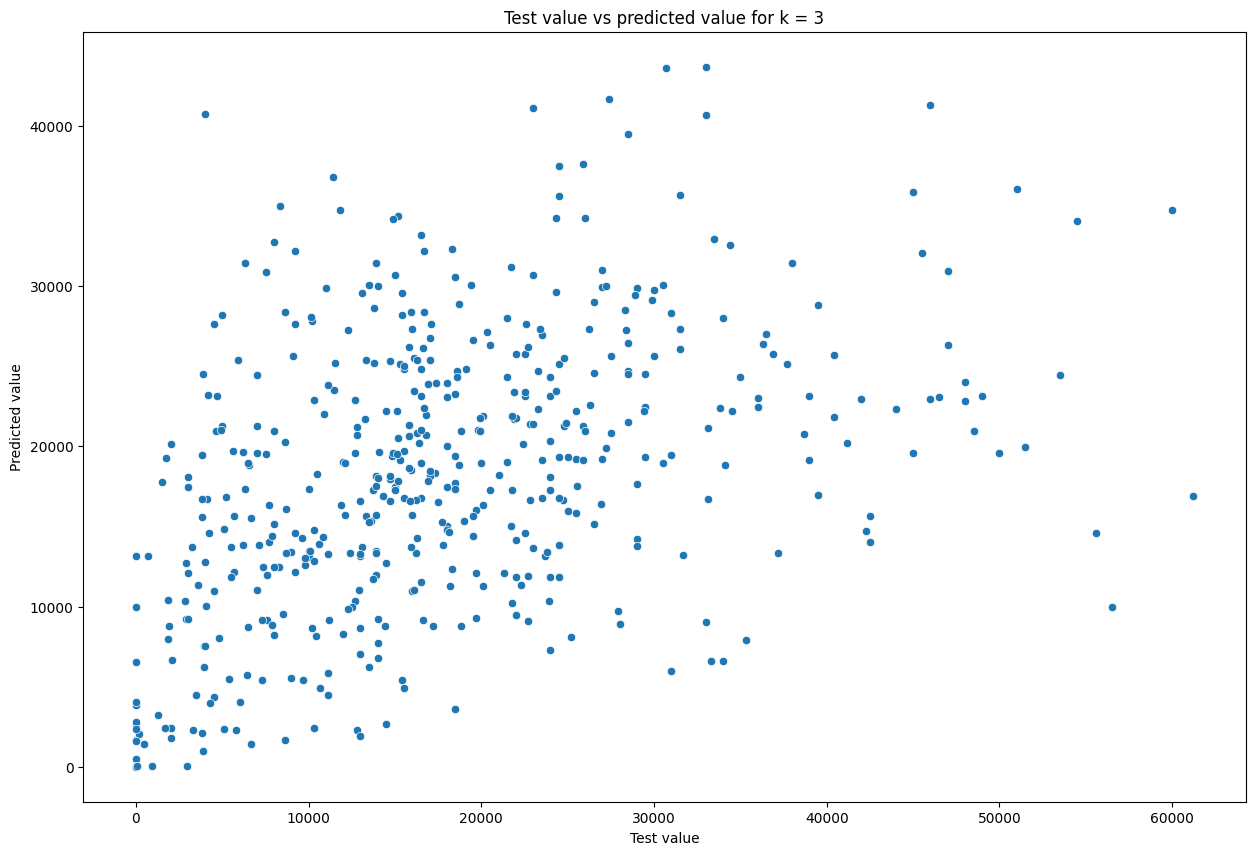

MSE for k = 3: 126118037.16488889


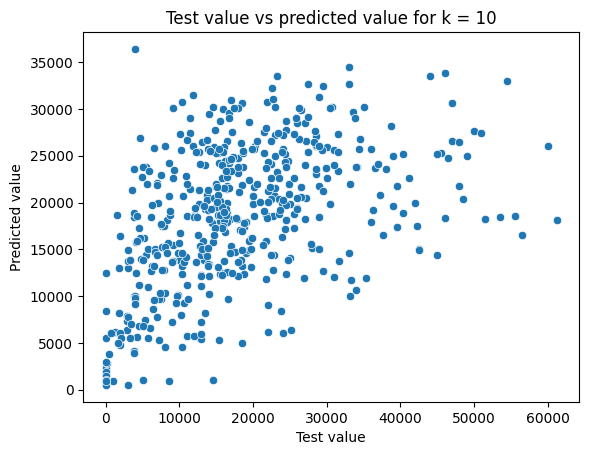

MSE for k = 10: 110653044.18681999


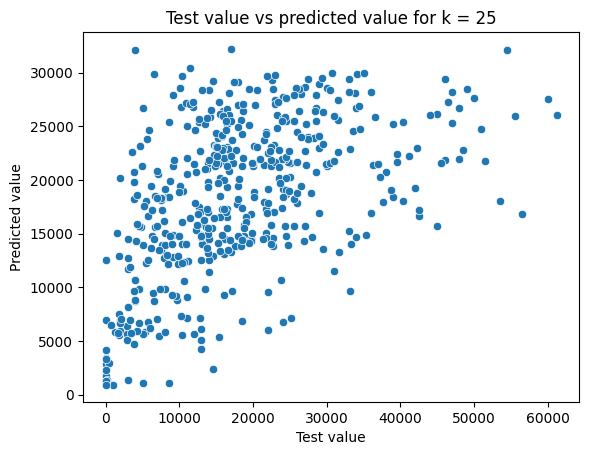

MSE for k = 25: 103174289.15223679


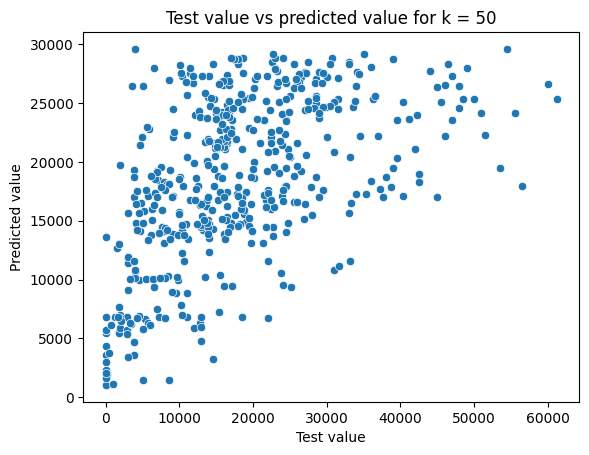

MSE for k = 50: 99685489.499396


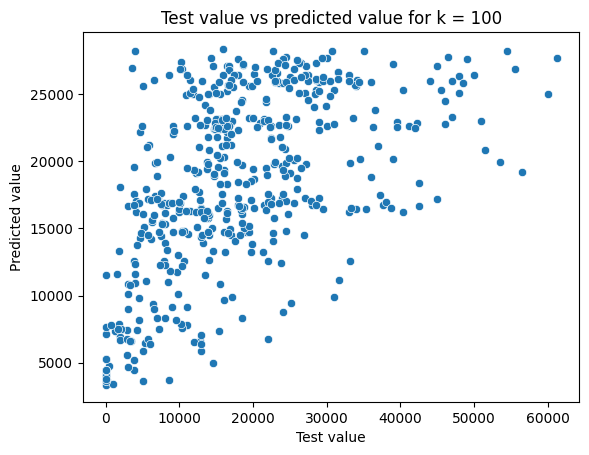

MSE for k = 100: 98276515.02300058


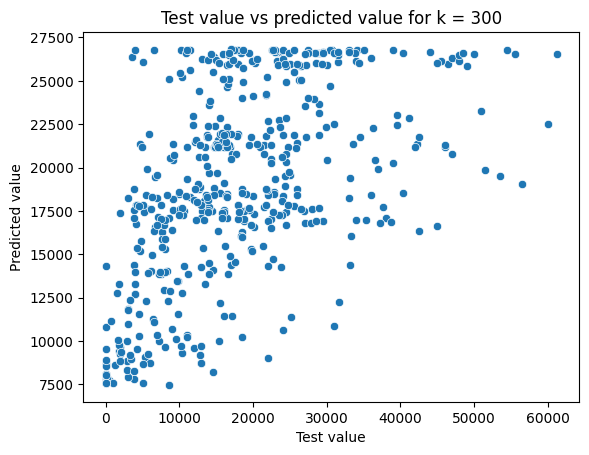

MSE for k = 300: 100477298.914212
As k increases, the predictions start to get closer together and flatten horizontally. As it gets too high, the model begins to predict the 'average' price for almost every car, losing its ability to distinguish high-value from low-value vehicles.


In [205]:
from sklearn.neighbors import KNeighborsRegressor

k_list=[3,10,25,50,100,300]

def mse(y_test,y_hat):
    mse = np.sum( (y_test - y_hat) ** 2 )/len(y_test)
    return mse

plt.figure(figsize=(15, 10))

for k in (k_list):
    model = KNeighborsRegressor(n_neighbors = k)
    model = model.fit(u2_train, y2_train)
    y2_hat = model.predict(u2_test)
    sns.scatterplot(x=y2_test, y=y2_hat)
    plt.ylabel("Predicted value")
    plt.xlabel("Test value")
    plt.title(f"Test value vs predicted value for k = {k}")
    plt.show()
    print(f"MSE for k = {k}: {mse(y2_test,y2_hat)}")

print("As k increases, the predictions start to get closer together and flatten horizontally. As it gets too high, the model begins to predict the 'average' price for almost every car, losing its ability to distinguish high-value from low-value vehicles.")

#5
Of the given ks, the best k is k = 100 as its MSE is the lowest. We want to minimize MSE, and k = 100 has the lowest MSE. 

#6
When k was very small (3), the predictions and test values were incredibly scattered, with many outliers; this is called overfitting. The scatterplot shows points spread out but trying to follow individual "noisy" data points from the training set. It is "overfitting" because it captures the random fluctuations of the nearest 3 points rather than general trends.

When k was very large (300), the predictions and test values got closer together and flattened horizontally; this is called underfitting. The model is taking the average of so many points that every prediction is nearly the same (the mean of the training set). It "underfits" because it is too simple to recognize the differences between points very far apart.

In between these extremes, the predictions and test values appeared to cluster together and show less error. At these ks, the model is complex enough to see the relationships needed, but simple enough to ignore the "noise" of individual outliers. 

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [219]:
#1
ABNB = pd.read_csv("../data/airbnb_hw.csv")
ABNB = ABNB.loc[:, ['Review Scores Rating', 'Price', 'Beds']]
ABNB['Price'] = pd.to_numeric(ABNB['Price'], errors='coerce')
ABNB['Beds'] = pd.to_numeric(ABNB['Beds'], errors='coerce')
print(ABNB.head(), "\n")
print(ABNB.shape, "\n")

   Review Scores Rating  Price  Beds
0                   NaN  145.0   1.0
1                   NaN   37.0   1.0
2                   NaN   28.0   1.0
3                   NaN  199.0   3.0
4                  96.0  549.0   3.0 

(30478, 3) 



In [220]:
#2
ABNB_null = ABNB.loc[ABNB['Review Scores Rating'].isnull()]
print(f"Number of missing ratings: {len(ABNB_null)}")
ABNB_null.head()

Number of missing ratings: 8323


,Review Scores Rating,Price,Beds
0,NaN,145.0,1.0
1,NaN,37.0,1.0
2,NaN,28.0,1.0
3,NaN,199.0,3.0
13,NaN,68.0,1.0


In [221]:
#3
ABNB = ABNB.dropna(axis=0, how = 'any')
print(ABNB.shape)
ABNB.head()

(22060, 3)


,Review Scores Rating,Price,Beds
4,96.0,549.0,3.0
5,100.0,149.0,1.0
6,100.0,250.0,1.0
7,94.0,90.0,1.0
8,90.0,270.0,2.0


In [222]:
#4
ua = ABNB.loc[:,['Price', 'Beds']]
ua = ua.apply(minmax)
ua.head()
ya = ABNB['Review Scores Rating']
ua_train, ua_test, ya_train, ya_test = train_test_split(ua,ya, test_size=.2, random_state=100)

mses = []
k_grid = np.arange(1, 51, 2)
test_accuracies = []
train_accuracies = []

for k in k_grid:     
    model = KNeighborsRegressor(n_neighbors = k)
    model = model.fit(ua_train, ya_train)
    ya_hat = model.predict(ua_test)
    mses.append(mse(ya_test, ya_hat))

best_k = k_grid[np.argmin(mses)]
print(f"Optimal k: {best_k}")
print("I chose k based on the lowest possible MSE.")

Optimal k: 43
I chose k based on the lowest possible MSE.


In [234]:
#5
model = KNeighborsRegressor(n_neighbors=best_k)
ua_scaled = ABNB[['Price', 'Beds']].apply(minmax)
y_values = ABNB['Review Scores Rating']
model.fit(ua_scaled,y_values)
X_missing = ABNB_null[['Price', 'Beds']].apply(minmax)
imputed_ratings = model.predict(X_missing.dropna())
print(imputed_ratings)

[94.27906977 89.65116279 84.90697674 ... 91.1627907  86.81395349
 91.1627907 ]


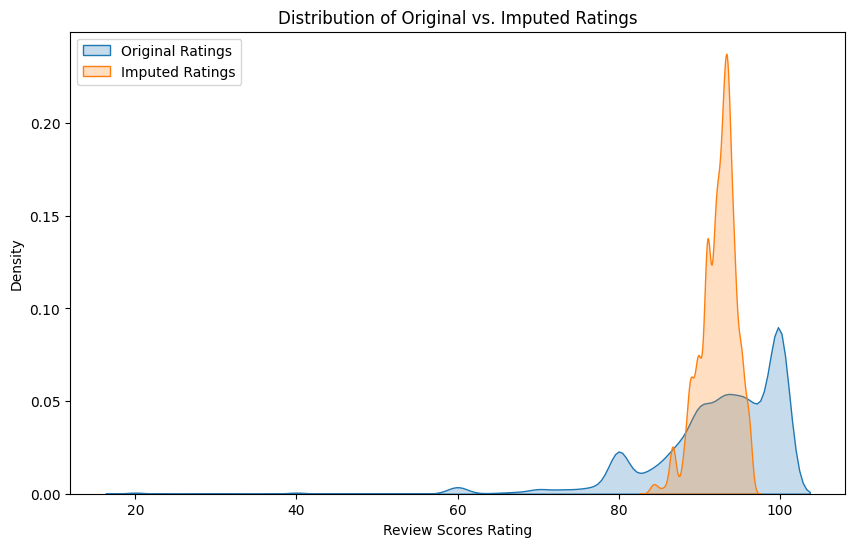

In [235]:
#6
plt.figure(figsize=(10, 6))
sns.kdeplot(ya_train, label='Original Ratings', fill=True)
sns.kdeplot(imputed_ratings, label='Imputed Ratings', fill=True)
plt.title("Distribution of Original vs. Imputed Ratings")
plt.xlabel("Review Scores Rating")
plt.legend()
plt.show()